# Continuous-time linear demo


In [1]:
import jax
from jax import config


config.update("jax_enable_x64", True)

from cmap.clqt_jax import CLQT
from cmap.Linear_model_jax import getCLQT 
import matplotlib.pyplot as plt
import jax.numpy as jnp
from cmap.Linear_model_data import make_cv_data
from cmap.con_to_dis import y
# config.update("jax_platform_name", "cuda")


In [2]:
from cmap.kalman_bucy import kalman_bucy_filter
from cmap.kalman_bucy import continuous_rts_smoother


In [3]:
from cmap.clqt_jax import seqBackwardPass
from cmap.clqt_jax import seqForwardPass
from cmap.clqt_jax import parBackwardPass
from cmap.clqt_jax import parForwardPass


In [4]:
steps_all=50000

In [5]:
clqt, x0,P0,q,v = getCLQT(CLQT,steps_all)

In [6]:
t0=0.0
dt=clqt.T/steps_all

q=q
r=v
X,y_discrete,y_discrete_rev=make_cv_data( x0, P0(0),steps_all, dt, q, r, seed=123)

In [7]:
y_meas=lambda t: y(t,dt,steps_all,y_discrete)

In [8]:
t_grid = jnp.arange(steps_all) * dt
s=jnp.stack([y_meas(t) for t in t_grid], axis=0)
DY_dt_recovered = jnp.stack([y_meas(t) for t in t_grid], axis=0)
jnp.shape(DY_dt_recovered)
# np.savetxt('con-meas.txt',dotz)

(50000, 2)

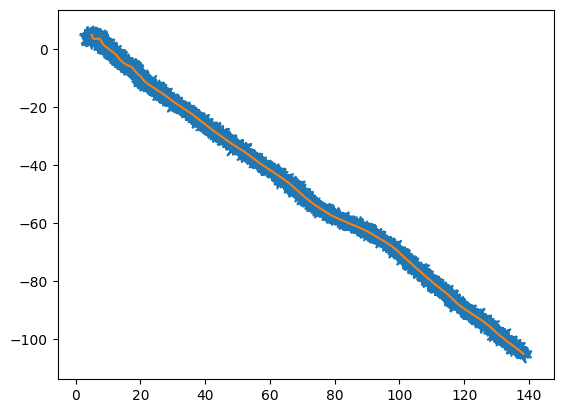

In [9]:
plt.plot(DY_dt_recovered[:,0], DY_dt_recovered[:,1], label='True velocity x')
plt.plot(X[:,0], X[:,1], label='True velocity x')


In [10]:
T=clqt.T
F=lambda t: -clqt.F(T-t)
L=lambda t: -clqt.L(T-t)
H=lambda t: clqt.H(T-t)
W=lambda t: clqt.W(T-t)
R=lambda t: clqt.R(T-t)



step_seq=steps_all
print(step_seq)

dt=clqt.T/step_seq

t_eval = t0 + dt * jnp.arange(step_seq)

Ps,ms = kalman_bucy_filter(F, L, W, H, R, y_meas, step_seq, dt,t0, P0(0), x0)
ms_s, Ps_s = continuous_rts_smoother(Ps, ms, F, L, W, t_eval, dt)


50000


In [11]:

blocks = 500
steps = 100
T=clqt.T
dt = clqt.T / steps / blocks
sigma=clqt.Sigma(0)
mu=clqt.mu

S_list_jax_seq, v_list_jax_seq,Kx_list_jax_seq, d_list_jax_seq = seqBackwardPass(clqt,steps*blocks,dt,t0,sigma,mu)
f1=lambda dt,t0,sigma,mu: seqBackwardPass(clqt,steps*blocks,dt,t0,sigma,mu)
jit_fun = jax.jit(f1)
jit_fun(dt,t0,sigma,mu)


phi0= jnp.linalg.solve(S_list_jax_seq[0] ,v_list_jax_seq[0])
x_list_jax_seq,u_list_jax_seq =seqForwardPass(clqt, dt, T, phi0, Kx_list_jax_seq, d_list_jax_seq,u_zoh=False)
f2=lambda dt, T, phi0, Kx_list_jax_seq, d_list_jax_seq: seqForwardPass(clqt, dt, T, phi0, Kx_list_jax_seq, d_list_jax_seq,u_zoh=False)
jit_fun = jax.jit(f2)
jit_fun(dt, T, phi0, Kx_list_jax_seq, d_list_jax_seq)


(Array([[ 1.38178500e+02, -1.05015523e+02,  2.73001232e+00,
         -2.71469405e+00],
        [ 1.38175770e+02, -1.05012808e+02,  2.73001232e+00,
         -2.71469405e+00],
        [ 1.38173040e+02, -1.05010093e+02,  2.73001256e+00,
         -2.71469463e+00],
        ...,
        [ 5.02597642e+00,  4.97624641e+00, -1.24767538e-02,
          4.99703118e-03],
        [ 5.02598889e+00,  4.97624141e+00, -1.22358209e-02,
          4.89996221e-03],
        [ 5.02600113e+00,  4.97623651e+00, -1.19954790e-02,
          4.80344777e-03]], dtype=float64),
 Array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         -2.27373675e-13],
        [ 0.00000000e+00,  0.00000000e+00,  2.39311491e-04,
         -5.76995943e-04],
        [ 0.00000000e+00,  0.00000000e+00,  4.49013231e-04,
         -1.01104070e-03],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  2.41532783e-01,
         -9.73108715e-02],
        [ 0.00000000e+00,  0.00000000e+00,  2.40932923e-01,
         -9.70689731e-02],


In [12]:
phis=jnp.linalg.solve(S_list_jax_seq ,v_list_jax_seq)


/Users/razavis2/anaconda3/envs/pcmap/lib/python3.9/site-packages/jax/_src/numpy/linalg.py:1342: FutureWarning: jnp.linalg.solve: batched 1D solves with b.ndim > 1 are deprecated, and in the future will be treated as a batched 2D solve. Use solve(a, b[..., None])[..., 0] to avoid this warning.
  warnings.warn("jnp.linalg.solve: batched 1D solves with b.ndim > 1 are deprecated, "


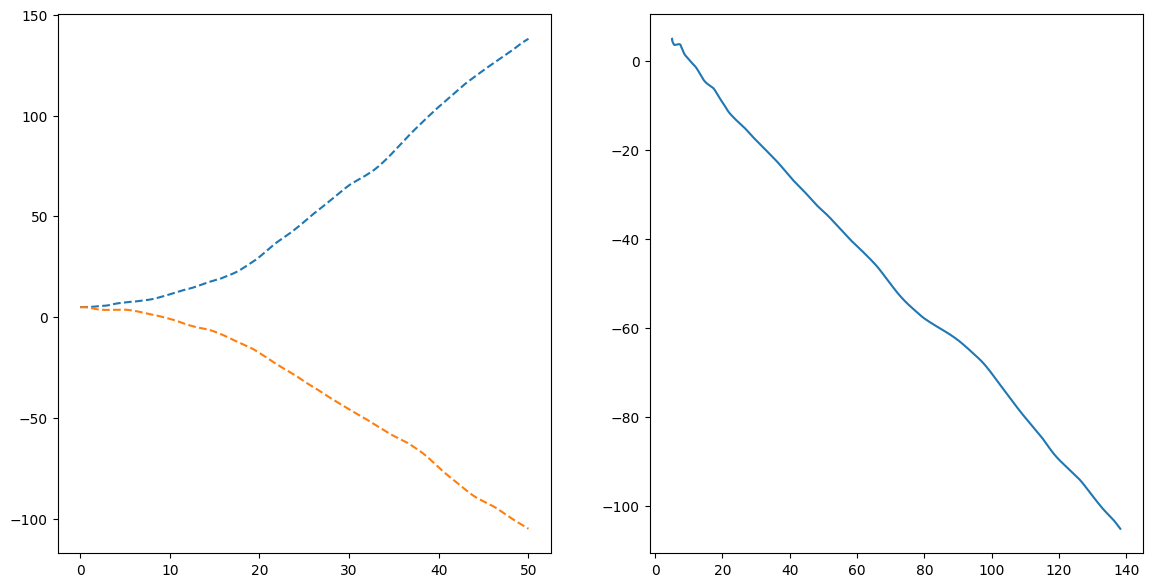

In [13]:
xs3 = jnp.array(x_list_jax_seq)[::-1]
us3 = jnp.array(u_list_jax_seq)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/ blocks
f, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs3[:,0], '--', tt1, xs3[:,1], '--')


ax2.plot(xs3[:,0], xs3[:,1])


In [14]:
dt = clqt.T / steps / blocks

Kx_list, d_list, S_list, v_list = parBackwardPass(clqt,blocks,steps,t0,dt)
f3=lambda t0,dt: parBackwardPass(clqt,blocks,steps,t0,dt)
jit_fun = jax.jit(f3)
Kx_list, d_list, S_list, v_list=jit_fun(t0,dt)

print(Kx_list.shape)


phi0= jnp.linalg.solve(S_list[0] ,v_list[0])

u_list,x_list = parForwardPass(clqt, phi0, Kx_list, d_list, blocks, steps,dt,t0,u_zoh=False)
f4=lambda phi0, Kx_list, d_list,dt,t0:parForwardPass(clqt, phi0, Kx_list, d_list, blocks, steps,dt,t0,u_zoh=False)
jit_fun = jax.jit(f4)
jit_fun(phi0, Kx_list, d_list,dt,t0)



(50000, 4, 4)


(Array([[ 0.        ,  0.        , -0.00414343,  0.00413327],
        [ 0.        ,  0.        , -0.00385231,  0.00350477],
        [ 0.        ,  0.        , -0.00359117,  0.00301964],
        ...,
        [ 0.        ,  0.        ,  0.23957742, -0.09668055],
        [ 0.        ,  0.        ,  0.23897669, -0.0964357 ],
        [ 0.        ,  0.        ,  0.23838473, -0.09587821]],      dtype=float64),
 Array([[ 1.38176702e+02, -1.05013454e+02,  2.73272067e+00,
         -2.71630959e+00],
        [ 1.38173969e+02, -1.05010738e+02,  2.73271652e+00,
         -2.71630545e+00],
        [ 1.38171236e+02, -1.05008021e+02,  2.73271267e+00,
         -2.71630195e+00],
        ...,
        [ 5.02598305e+00,  4.97611562e+00, -1.23749372e-02,
          4.96380447e-03],
        [ 5.02599542e+00,  4.97611065e+00, -1.21359605e-02,
          4.86736877e-03],
        [ 5.02600756e+00,  4.97610579e+00, -1.18975758e-02,
          4.77149056e-03]], dtype=float64))

In [15]:
phis1=jnp.linalg.solve(S_list ,v_list)


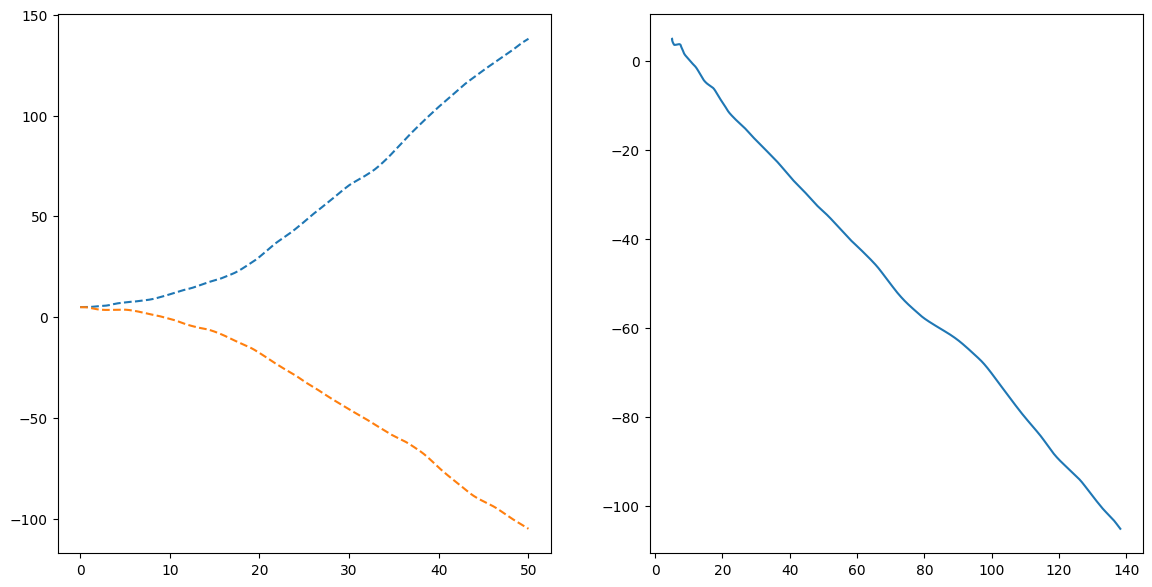

In [16]:
xs4 = jnp.array(x_list)[::-1]

us4 = jnp.array(u_list)
tt1 = jnp.arange(0, (blocks*steps)+1) * clqt.T  / steps/blocks


ff, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))
ax1.plot(tt1, xs4[:,0], '--', tt1, xs4[:,1], '--')
ax2.plot(xs4[:,0], xs4[:,1])


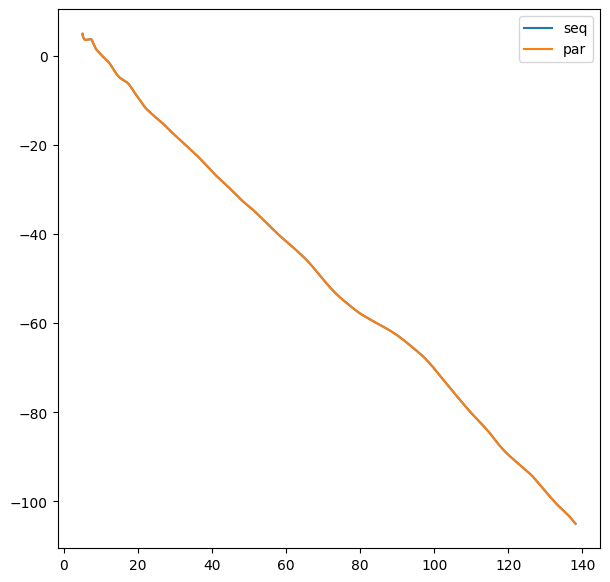

In [17]:
f, (ax1) = plt.subplots(1, figsize=(7,7))

ax1.plot(xs3[:,0], xs3[:,1])
ax1.plot( xs4[:,0],xs4[:,1])
ax1.legend( ['seq', 'par'])


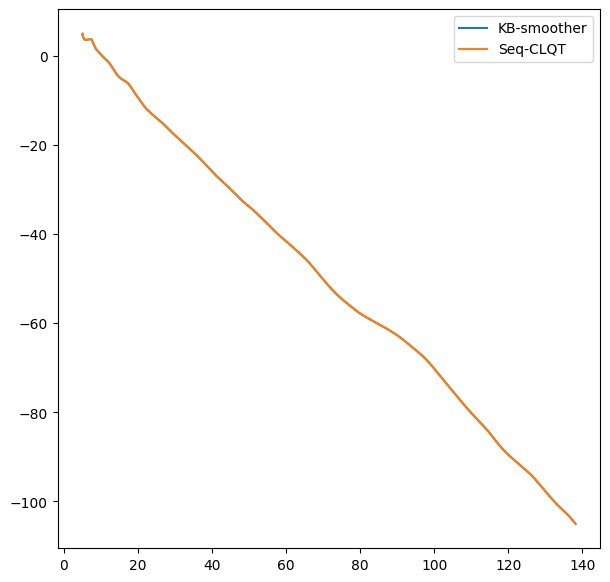

In [18]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms_s[:,0], ms_s[:,1])
ax1.plot(xs3[:,0], xs3[:,1])
ax1.legend( ['KB-smoother', 'Seq-CLQT'])


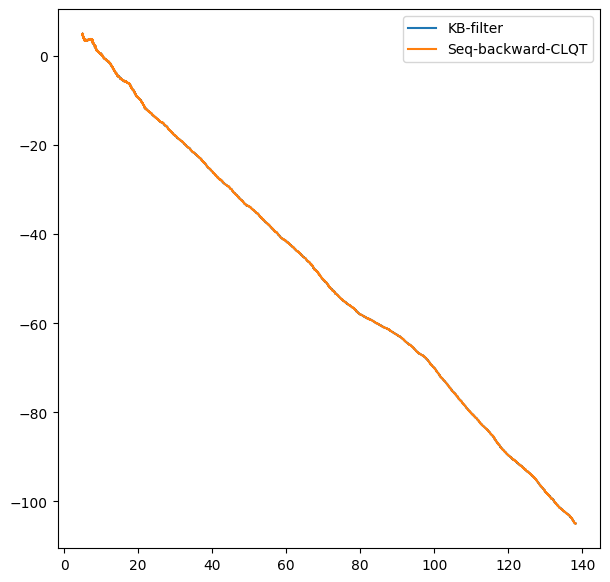

In [19]:
f, (ax1) = plt.subplots(1,1, figsize=(7,7))

ax1.plot(ms[:,0], ms[:,1])
ax1.plot(phis[:,0], phis[:,1])
ax1.legend( ['KB-filter', 'Seq-backward-CLQT'])


In [20]:
err = jnp.max(jnp.abs(xs4- xs3))
print(err)

0.004560356709262692


In [21]:
print(jnp.max(jnp.abs(xs3-ms_s)))

0.004861730663932917


In [22]:
print(jnp.max(jnp.abs(phis[::-1]-ms)))

0.0008173303799441922


In [23]:
jax.numpy.allclose(xs3, xs4, rtol=1e-1)

Array(False, dtype=bool)

In [24]:
jax.numpy.allclose(xs3, ms_s, rtol=1e-1)

Array(False, dtype=bool)

In [25]:
jax.numpy.allclose(phis[::-1], ms, rtol=1e-3)

Array(False, dtype=bool)